# 07 Train Transformer Encoder Model on WLASL100

This notebook trains a small Transformer Encoder model on the WLASL100 MediaPipe keypoint dataset.

The goal is to compare a Transformer-based sequence model against the improved BiGRU + Temporal Attention model.

The Transformer model uses:

- global train-set normalisation
- velocity / motion features
- balanced class sampling
- input projection
- learnable positional encoding
- Transformer Encoder layers
- attention-style CLS token pooling
- AdamW optimiser
- learning-rate scheduling
- gradient clipping
- early stopping
- Top-1, Top-3, Top-5 accuracy
- Macro F1-score

This is still WLASL100, so the goal is not only high accuracy. The goal is to test whether Transformer attention improves fine-grained sign separation before scaling to WLASL300.

In [1]:
from pathlib import Path
import json
import random
import time
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler

from tqdm.auto import tqdm
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

warnings.filterwarnings("ignore", category=UserWarning)

e:\Be_My_Ear\.venv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

PROJECT_ROOT = Path("E:/Be_My_Ear")

BASE_DIR = PROJECT_ROOT / "data" / "processed" / "ASL" / "WLASL100"
CLEAN_INDEX_FILE = BASE_DIR / "wlasl100_clean_keypoint_index.csv"
LABEL_MAP_FILE = PROJECT_ROOT / "data" / "label_maps" / "asl_wlasl100_labels.json"

MODEL_DIR = PROJECT_ROOT / "models" / "ASL" / "WLASL100"
MODEL_DIR.mkdir(parents=True, exist_ok=True)

MODEL_PATH = MODEL_DIR / "transformer_encoder_wlasl100.pt"
HISTORY_PATH = MODEL_DIR / "transformer_encoder_wlasl100_history.csv"
NORM_STATS_PATH = MODEL_DIR / "wlasl100_train_norm_stats.npz"

print("Clean index exists:", CLEAN_INDEX_FILE.exists())
print("Label map exists:", LABEL_MAP_FILE.exists())
print("Normalisation stats exists:", NORM_STATS_PATH.exists())
print("Model will save to:", MODEL_PATH)

Clean index exists: True
Label map exists: True
Normalisation stats exists: True
Model will save to: E:\Be_My_Ear\models\ASL\transformer_encoder_wlasl100.pt


In [3]:
df = pd.read_csv(CLEAN_INDEX_FILE)

print("Total clean samples:", len(df))
print("Total classes:", df["label_id"].nunique())
print("Input shape per original file should be: (60, 258)")
print("Example keypoint path:", df.iloc[0]["keypoint_path"])

df.head()

Total clean samples: 1013
Total classes: 100
Input shape per original file should be: (60, 258)
Example keypoint path: E:\Be_My_Ear\data\processed\ASL\WLASL100\keypoints\69422.npy


,video_id,gloss,label_id,original_class_id,video_path,keypoint_path,zero_ratio
0,69422,orange,67,27,E:\Be_My_Ear\data\raw\ASL\videos\69422.mp4,E:\Be_My_Ear\data\processed\ASL\WLASL100\keypo...,0.321512
1,10898,city,20,82,E:\Be_My_Ear\data\raw\ASL\videos\10898.mp4,E:\Be_My_Ear\data\processed\ASL\WLASL100\keypo...,0.126163
2,10893,city,20,82,E:\Be_My_Ear\data\raw\ASL\videos\10893.mp4,E:\Be_My_Ear\data\processed\ASL\WLASL100\keypo...,0.264535
3,10892,city,20,82,E:\Be_My_Ear\data\raw\ASL\videos\10892.mp4,E:\Be_My_Ear\data\processed\ASL\WLASL100\keypo...,0.170930
4,10895,city,20,82,E:\Be_My_Ear\data\raw\ASL\videos\10895.mp4,E:\Be_My_Ear\data\processed\ASL\WLASL100\keypo...,0.464341


## 1. Recreate the same train / validation / test split

We use the same split strategy as the improved BiGRU notebook. This makes comparison fair.

In [4]:
train_records = []
val_records = []
test_records = []

for label_id, group in df.groupby("label_id"):
    group = group.sample(frac=1, random_state=SEED).reset_index(drop=True)

    n = len(group)

    n_test = max(1, int(round(n * 0.15)))
    n_val = max(1, int(round(n * 0.15)))

    test_part = group.iloc[:n_test]
    val_part = group.iloc[n_test:n_test + n_val]
    train_part = group.iloc[n_test + n_val:]

    train_records.append(train_part)
    val_records.append(val_part)
    test_records.append(test_part)

train_df = pd.concat(train_records).sample(frac=1, random_state=SEED).reset_index(drop=True)
val_df = pd.concat(val_records).sample(frac=1, random_state=SEED).reset_index(drop=True)
test_df = pd.concat(test_records).sample(frac=1, random_state=SEED).reset_index(drop=True)

print("Train samples:", len(train_df))
print("Validation samples:", len(val_df))
print("Test samples:", len(test_df))

print("Train classes:", train_df["label_id"].nunique())
print("Validation classes:", val_df["label_id"].nunique())
print("Test classes:", test_df["label_id"].nunique())

Train samples: 697
Validation samples: 158
Test samples: 158
Train classes: 100
Validation classes: 100
Test classes: 100


## 2. Load or compute global normalisation statistics

The Transformer uses the same global train-set normalisation approach as the improved BiGRU model. If the stats file already exists, it will be loaded. Otherwise, it will be recomputed from the training split.

In [5]:
def compute_train_normalisation_stats(train_dataframe):
    total_sum = None
    total_sq_sum = None
    total_count = 0

    for path in tqdm(train_dataframe["keypoint_path"], desc="Computing train mean/std"):
        arr = np.load(path).astype(np.float32)

        if total_sum is None:
            total_sum = arr.sum(axis=0)
            total_sq_sum = (arr ** 2).sum(axis=0)
        else:
            total_sum += arr.sum(axis=0)
            total_sq_sum += (arr ** 2).sum(axis=0)

        total_count += arr.shape[0]

    mean = total_sum / total_count
    variance = (total_sq_sum / total_count) - (mean ** 2)
    variance = np.maximum(variance, 1e-6)
    std = np.sqrt(variance)

    return mean.astype(np.float32), std.astype(np.float32)


if NORM_STATS_PATH.exists():
    norm_stats = np.load(NORM_STATS_PATH)
    train_mean = norm_stats["mean"].astype(np.float32)
    train_std = norm_stats["std"].astype(np.float32)
    print("Loaded normalisation stats from:", NORM_STATS_PATH)
else:
    train_mean, train_std = compute_train_normalisation_stats(train_df)
    np.savez(NORM_STATS_PATH, mean=train_mean, std=train_std)
    print("Recomputed and saved normalisation stats to:", NORM_STATS_PATH)

print("Mean shape:", train_mean.shape)
print("Std shape:", train_std.shape)

Loaded normalisation stats from: E:\Be_My_Ear\models\ASL\wlasl100_train_norm_stats.npz
Mean shape: (258,)
Std shape: (258,)


## 3. Dataset with velocity features

Original keypoints are `(60, 258)`. We add velocity features so the model receives `(60, 516)`.

This helps because sign language is based on both position and movement.

In [6]:
class TransformerSignDataset(Dataset):
    def __init__(self, dataframe, mean, std, use_velocity=True):
        self.dataframe = dataframe.reset_index(drop=True)
        self.mean = mean.reshape(1, -1).astype(np.float32)
        self.std = std.reshape(1, -1).astype(np.float32)
        self.use_velocity = use_velocity

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        row = self.dataframe.iloc[idx]

        keypoints = np.load(row["keypoint_path"]).astype(np.float32)

        # Global train-set normalisation
        keypoints = (keypoints - self.mean) / (self.std + 1e-6)

        if self.use_velocity:
            velocity = np.zeros_like(keypoints, dtype=np.float32)
            velocity[1:] = keypoints[1:] - keypoints[:-1]
            features = np.concatenate([keypoints, velocity], axis=1)
        else:
            features = keypoints

        label = int(row["label_id"])

        features = torch.tensor(features, dtype=torch.float32)
        label = torch.tensor(label, dtype=torch.long)

        return features, label

In [7]:
BATCH_SIZE = 32
USE_VELOCITY = True
INPUT_SIZE = 516 if USE_VELOCITY else 258
SEQUENCE_LENGTH = 60

train_dataset = TransformerSignDataset(train_df, train_mean, train_std, use_velocity=USE_VELOCITY)
val_dataset = TransformerSignDataset(val_df, train_mean, train_std, use_velocity=USE_VELOCITY)
test_dataset = TransformerSignDataset(test_df, train_mean, train_std, use_velocity=USE_VELOCITY)

x_sample, y_sample = train_dataset[0]

print("Single sample feature shape:", x_sample.shape)
print("Single sample label:", y_sample)
print("Input size:", INPUT_SIZE)

Single sample feature shape: torch.Size([60, 516])
Single sample label: tensor(23)
Input size: 516


## 4. Balanced sampling

The model sees underrepresented classes more often during training.

In [8]:
train_label_counts = train_df["label_id"].value_counts().sort_index()
class_sample_counts = train_label_counts.to_dict()

sample_weights = train_df["label_id"].map(lambda label: 1.0 / class_sample_counts[label]).values
sample_weights = torch.DoubleTensor(sample_weights)

train_sampler = WeightedRandomSampler(
    weights=sample_weights,
    num_samples=len(sample_weights),
    replacement=True
)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    sampler=train_sampler,
    num_workers=0
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0
)

x_batch, y_batch = next(iter(train_loader))

print("Input batch shape:", x_batch.shape)
print("Label batch shape:", y_batch.shape)

Input batch shape: torch.Size([32, 60, 516])
Label batch shape: torch.Size([32])


## 5. Small Transformer Encoder model

This model uses a learnable `[CLS]` token. The Transformer reads the full 60-frame sequence, and the final `[CLS]` representation is used for classification.

In [9]:
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=128, dropout=0.1):
        super(PositionalEncoding, self).__init__()

        self.dropout = nn.Dropout(dropout)

        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float32).unsqueeze(1)

        div_term = torch.exp(
            torch.arange(0, d_model, 2).float() * (-np.log(10000.0) / d_model)
        )

        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)

        pe = pe.unsqueeze(0)
        self.register_buffer("pe", pe)

    def forward(self, x):
        # x shape: (batch, seq_len, d_model)
        seq_len = x.size(1)
        x = x + self.pe[:, :seq_len, :]
        return self.dropout(x)

In [10]:
class SignTransformerEncoder(nn.Module):
    def __init__(
        self,
        input_size,
        num_classes,
        d_model=256,
        nhead=4,
        num_layers=3,
        dim_feedforward=512,
        dropout=0.3,
        max_len=61
    ):
        super(SignTransformerEncoder, self).__init__()

        self.input_projection = nn.Sequential(
            nn.Linear(input_size, d_model),
            nn.LayerNorm(d_model),
            nn.ReLU(),
            nn.Dropout(dropout)
        )

        self.cls_token = nn.Parameter(torch.zeros(1, 1, d_model))
        self.positional_encoding = PositionalEncoding(
            d_model=d_model,
            max_len=max_len,
            dropout=dropout
        )

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=nhead,
            dim_feedforward=dim_feedforward,
            dropout=dropout,
            batch_first=True,
            activation="gelu",
            norm_first=True
        )

        self.transformer_encoder = nn.TransformerEncoder(
            encoder_layer=encoder_layer,
            num_layers=num_layers
        )

        self.classifier = nn.Sequential(
            nn.LayerNorm(d_model),
            nn.Linear(d_model, d_model),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(d_model, num_classes)
        )

        self._init_weights()

    def _init_weights(self):
        nn.init.normal_(self.cls_token, std=0.02)

    def forward(self, x):
        # x shape: (batch, 60, input_size)
        batch_size = x.size(0)

        x = self.input_projection(x)

        cls_tokens = self.cls_token.expand(batch_size, -1, -1)
        x = torch.cat([cls_tokens, x], dim=1)  # (batch, 61, d_model)

        x = self.positional_encoding(x)

        encoded = self.transformer_encoder(x)

        cls_output = encoded[:, 0, :]

        logits = self.classifier(cls_output)

        return logits

In [11]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

NUM_CLASSES = df["label_id"].nunique()

model = SignTransformerEncoder(
    input_size=INPUT_SIZE,
    num_classes=NUM_CLASSES,
    d_model=256,
    nhead=4,
    num_layers=3,
    dim_feedforward=512,
    dropout=0.3,
    max_len=SEQUENCE_LENGTH + 1
).to(device)

criterion = nn.CrossEntropyLoss(label_smoothing=0.05)

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=2e-4,
    weight_decay=1e-4
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="max",
    factor=0.5,
    patience=5
)

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(model)
print("Total parameters:", total_params)
print("Trainable parameters:", trainable_params)

Using device: cpu
SignTransformerEncoder(
  (input_projection): Sequential(
    (0): Linear(in_features=516, out_features=256, bias=True)
    (1): LayerNorm((256,), eps=1e-05, elementwise_affine=True, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
  )
  (positional_encoding): PositionalEncoding(
    (dropout): Dropout(p=0.3, inplace=False)
  )
  (transformer_encoder): TransformerEncoder(
    (layers): ModuleList(
      (0-2): 3 x TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=256, out_features=256, bias=True)
        )
        (linear1): Linear(in_features=256, out_features=512, bias=True)
        (dropout): Dropout(p=0.3, inplace=False)
        (linear2): Linear(in_features=512, out_features=256, bias=True)
        (norm1): LayerNorm((256,), eps=1e-05, elementwise_affine=True, bias=True)
        (norm2): LayerNorm((256,), eps=1e-05, elementwise_affine=True, bias=True)
        (dropo

## 6. Metrics and training helpers

In [12]:
def top_k_accuracy(outputs, labels, k=5):
    _, top_k_preds = outputs.topk(k, dim=1)
    correct = top_k_preds.eq(labels.view(-1, 1).expand_as(top_k_preds))
    return correct.any(dim=1).float().mean().item()


def get_current_lr(optimizer):
    return optimizer.param_groups[0]["lr"]

In [13]:
def train_one_epoch(model, loader, optimizer, criterion, device, epoch, total_epochs):
    model.train()

    total_loss = 0
    total_top1 = 0
    total_top3 = 0
    total_top5 = 0

    all_preds = []
    all_labels = []

    progress_bar = tqdm(
        loader,
        desc=f"Epoch {epoch}/{total_epochs} [Training]",
        leave=False
    )

    for step, (x, y) in enumerate(progress_bar, start=1):
        x = x.to(device)
        y = y.to(device)

        optimizer.zero_grad()

        outputs = model(x)
        loss = criterion(outputs, y)

        loss.backward()

        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

        optimizer.step()

        preds = torch.argmax(outputs, dim=1)

        batch_top1 = (preds == y).float().mean().item()
        batch_top3 = top_k_accuracy(outputs, y, k=3)
        batch_top5 = top_k_accuracy(outputs, y, k=5)

        total_loss += loss.item()
        total_top1 += batch_top1
        total_top3 += batch_top3
        total_top5 += batch_top5

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(y.cpu().numpy())

        progress_bar.set_postfix({
            "step": f"{step}/{len(loader)}",
            "loss": f"{loss.item():.4f}",
            "top1": f"{batch_top1:.4f}",
            "top5": f"{batch_top5:.4f}",
            "lr": f"{get_current_lr(optimizer):.6f}"
        })

    avg_loss = total_loss / len(loader)
    avg_top1 = total_top1 / len(loader)
    avg_top3 = total_top3 / len(loader)
    avg_top5 = total_top5 / len(loader)
    macro_f1 = f1_score(all_labels, all_preds, average="macro", zero_division=0)

    return avg_loss, avg_top1, avg_top3, avg_top5, macro_f1


def evaluate(model, loader, criterion, device, epoch, total_epochs, phase="Validation"):
    model.eval()

    total_loss = 0
    total_top1 = 0
    total_top3 = 0
    total_top5 = 0

    all_preds = []
    all_labels = []

    progress_bar = tqdm(
        loader,
        desc=f"Epoch {epoch}/{total_epochs} [{phase}]",
        leave=False
    )

    with torch.no_grad():
        for step, (x, y) in enumerate(progress_bar, start=1):
            x = x.to(device)
            y = y.to(device)

            outputs = model(x)
            loss = criterion(outputs, y)

            preds = torch.argmax(outputs, dim=1)

            batch_top1 = (preds == y).float().mean().item()
            batch_top3 = top_k_accuracy(outputs, y, k=3)
            batch_top5 = top_k_accuracy(outputs, y, k=5)

            total_loss += loss.item()
            total_top1 += batch_top1
            total_top3 += batch_top3
            total_top5 += batch_top5

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(y.cpu().numpy())

            progress_bar.set_postfix({
                "step": f"{step}/{len(loader)}",
                "loss": f"{loss.item():.4f}",
                "top1": f"{batch_top1:.4f}",
                "top5": f"{batch_top5:.4f}"
            })

    avg_loss = total_loss / len(loader)
    avg_top1 = total_top1 / len(loader)
    avg_top3 = total_top3 / len(loader)
    avg_top5 = total_top5 / len(loader)
    macro_f1 = f1_score(all_labels, all_preds, average="macro", zero_division=0)

    return avg_loss, avg_top1, avg_top3, avg_top5, macro_f1

## 7. Train Transformer model

This is a small Transformer. It may or may not beat the BiGRU + Attention model on WLASL100 because the dataset is small. The main goal is comparison.

In [14]:
EPOCHS = 60
EARLY_STOPPING_PATIENCE = 15

history = {
    "train_loss": [],
    "train_top1": [],
    "train_top3": [],
    "train_top5": [],
    "train_f1": [],
    "val_loss": [],
    "val_top1": [],
    "val_top3": [],
    "val_top5": [],
    "val_f1": [],
    "lr": []
}

best_val_f1 = 0.0
best_val_top5 = 0.0
epochs_without_improvement = 0

print("=" * 80)
print("Be My Ear - WLASL100 Transformer Encoder Training")
print("=" * 80)
print(f"Device: {device}")
print(f"Model: Small Transformer Encoder")
print(f"Input shape: (60, {INPUT_SIZE})")
print(f"Classes: {NUM_CLASSES}")
print(f"Train samples: {len(train_df)}")
print(f"Validation samples: {len(val_df)}")
print(f"Test samples: {len(test_df)}")
print(f"Epochs: {EPOCHS}")
print(f"Batch size: {BATCH_SIZE}")
print(f"Balanced sampler: Yes")
print(f"Velocity features: {USE_VELOCITY}")
print(f"Model save path: {MODEL_PATH}")
print("=" * 80)

start_time = time.time()

for epoch in range(1, EPOCHS + 1):
    print(f"\nEpoch {epoch}/{EPOCHS}")
    print("-" * 80)

    train_loss, train_top1, train_top3, train_top5, train_f1 = train_one_epoch(
        model, train_loader, optimizer, criterion, device, epoch, EPOCHS
    )

    val_loss, val_top1, val_top3, val_top5, val_f1 = evaluate(
        model, val_loader, criterion, device, epoch, EPOCHS, phase="Validation"
    )

    scheduler.step(val_f1)

    current_lr = get_current_lr(optimizer)

    history["train_loss"].append(train_loss)
    history["train_top1"].append(train_top1)
    history["train_top3"].append(train_top3)
    history["train_top5"].append(train_top5)
    history["train_f1"].append(train_f1)

    history["val_loss"].append(val_loss)
    history["val_top1"].append(val_top1)
    history["val_top3"].append(val_top3)
    history["val_top5"].append(val_top5)
    history["val_f1"].append(val_f1)
    history["lr"].append(current_lr)

    improved = val_f1 > best_val_f1

    if improved:
        best_val_f1 = val_f1
        best_val_top5 = val_top5
        epochs_without_improvement = 0

        torch.save({
            "epoch": epoch,
            "model_state_dict": model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "best_val_f1": best_val_f1,
            "best_val_top5": best_val_top5,
            "num_classes": NUM_CLASSES,
            "input_size": INPUT_SIZE,
            "sequence_length": SEQUENCE_LENGTH,
            "use_velocity": USE_VELOCITY,
            "architecture": "SignTransformerEncoder",
            "d_model": 256,
            "nhead": 4,
            "num_layers": 3,
            "dim_feedforward": 512,
            "dropout": 0.3
        }, MODEL_PATH)

        save_status = "Saved new best model"
    else:
        epochs_without_improvement += 1
        save_status = "No improvement"

    print(
        f"Train | Loss: {train_loss:.4f} | Top-1: {train_top1:.4f} | "
        f"Top-3: {train_top3:.4f} | Top-5: {train_top5:.4f} | F1: {train_f1:.4f}"
    )

    print(
        f"Val   | Loss: {val_loss:.4f} | Top-1: {val_top1:.4f} | "
        f"Top-3: {val_top3:.4f} | Top-5: {val_top5:.4f} | F1: {val_f1:.4f}"
    )

    print(f"Learning rate: {current_lr:.8f}")
    print(f"Status: {save_status}")
    print(f"Best Val F1 so far: {best_val_f1:.4f}")
    print(f"Best Val Top-5 so far: {best_val_top5:.4f}")
    print(f"Epochs without improvement: {epochs_without_improvement}/{EARLY_STOPPING_PATIENCE}")

    if epochs_without_improvement >= EARLY_STOPPING_PATIENCE:
        print("\nEarly stopping triggered.")
        break

end_time = time.time()
training_minutes = (end_time - start_time) / 60

print("\n" + "=" * 80)
print("Transformer training completed")
print("=" * 80)
print(f"Total training time: {training_minutes:.2f} minutes")
print(f"Best validation F1: {best_val_f1:.4f}")
print(f"Best validation Top-5: {best_val_top5:.4f}")
print(f"Best model saved to: {MODEL_PATH}")
print("=" * 80)

Be My Ear - WLASL100 Transformer Encoder Training
Device: cpu
Model: Small Transformer Encoder
Input shape: (60, 516)
Classes: 100
Train samples: 697
Validation samples: 158
Test samples: 158
Epochs: 60
Batch size: 32
Balanced sampler: Yes
Velocity features: True
Model save path: E:\Be_My_Ear\models\ASL\transformer_encoder_wlasl100.pt

Epoch 1/60
--------------------------------------------------------------------------------


Train | Loss: 4.6059 | Top-1: 0.0221 | Top-3: 0.0481 | Top-5: 0.0844 | F1: 0.0083
Val   | Loss: 4.6049 | Top-1: 0.0125 | Top-3: 0.0437 | Top-5: 0.0688 | F1: 0.0009
Learning rate: 0.00020000
Status: Saved new best model
Best Val F1 so far: 0.0009
Best Val Top-5 so far: 0.0688
Epochs without improvement: 0/15

Epoch 2/60
--------------------------------------------------------------------------------


Train | Loss: 4.5149 | Top-1: 0.0296 | Top-3: 0.0907 | Top-5: 0.1262 | F1: 0.0134
Val   | Loss: 4.5156 | Top-1: 0.0187 | Top-3: 0.0563 | Top-5: 0.0879 | F1: 0.0016
Learning rate: 0.00020000
Status: Saved new best model
Best Val F1 so far: 0.0016
Best Val Top-5 so far: 0.0879
Epochs without improvement: 0/15

Epoch 3/60
--------------------------------------------------------------------------------


Train | Loss: 4.4238 | Top-1: 0.0345 | Top-3: 0.0828 | Top-5: 0.1187 | F1: 0.0124
Val   | Loss: 4.4249 | Top-1: 0.0250 | Top-3: 0.0567 | Top-5: 0.0817 | F1: 0.0044
Learning rate: 0.00020000
Status: Saved new best model
Best Val F1 so far: 0.0044
Best Val Top-5 so far: 0.0817
Epochs without improvement: 0/15

Epoch 4/60
--------------------------------------------------------------------------------


Train | Loss: 4.3011 | Top-1: 0.0349 | Top-3: 0.1020 | Top-5: 0.1749 | F1: 0.0151
Val   | Loss: 4.3319 | Top-1: 0.0379 | Top-3: 0.0883 | Top-5: 0.1075 | F1: 0.0109
Learning rate: 0.00020000
Status: Saved new best model
Best Val F1 so far: 0.0109
Best Val Top-5 so far: 0.1075
Epochs without improvement: 0/15

Epoch 5/60
--------------------------------------------------------------------------------


...

Train | Loss: 1.2673 | Top-1: 0.8176 | Top-3: 0.9499 | Top-5: 0.9740 | F1: 0.7906
Val   | Loss: 2.6108 | Top-1: 0.3921 | Top-3: 0.6837 | Top-5: 0.7971 | F1: 0.3372
Learning rate: 0.00010000
Status: No improvement
Best Val F1 so far: 0.3492
Best Val Top-5 so far: 0.8042
Epochs without improvement: 1/15

Epoch 57/60
--------------------------------------------------------------------------------


Train | Loss: 1.2569 | Top-1: 0.8184 | Top-3: 0.9527 | Top-5: 0.9868 | F1: 0.7936
Val   | Loss: 2.6056 | Top-1: 0.3988 | Top-3: 0.6767 | Top-5: 0.7529 | F1: 0.3377
Learning rate: 0.00010000
Status: No improvement
Best Val F1 so far: 0.3492
Best Val Top-5 so far: 0.8042
Epochs without improvement: 2/15

Epoch 58/60
--------------------------------------------------------------------------------


Train | Loss: 1.2806 | Top-1: 0.8130 | Top-3: 0.9538 | Top-5: 0.9801 | F1: 0.7897
Val   | Loss: 2.6683 | Top-1: 0.3788 | Top-3: 0.6458 | Top-5: 0.7663 | F1: 0.3347
Learning rate: 0.00010000
Status: No improvement
Best Val F1 so far: 0.3492
Best Val Top-5 so far: 0.8042
Epochs without improvement: 3/15

Epoch 59/60
--------------------------------------------------------------------------------


Train | Loss: 1.2309 | Top-1: 0.8265 | Top-3: 0.9580 | Top-5: 0.9797 | F1: 0.8109
Val   | Loss: 2.6622 | Top-1: 0.4179 | Top-3: 0.6517 | Top-5: 0.7592 | F1: 0.3740
Learning rate: 0.00010000
Status: Saved new best model
Best Val F1 so far: 0.3740
Best Val Top-5 so far: 0.7592
Epochs without improvement: 0/15

Epoch 60/60
--------------------------------------------------------------------------------


Train | Loss: 1.2431 | Top-1: 0.8249 | Top-3: 0.9609 | Top-5: 0.9797 | F1: 0.8092
Val   | Loss: 2.6382 | Top-1: 0.4171 | Top-3: 0.6775 | Top-5: 0.7725 | F1: 0.3578
Learning rate: 0.00010000
Status: No improvement
Best Val F1 so far: 0.3740
Best Val Top-5 so far: 0.7592
Epochs without improvement: 1/15

Transformer training completed
Total training time: 6.96 minutes
Best validation F1: 0.3740
Best validation Top-5: 0.7592
Best model saved to: E:\Be_My_Ear\models\ASL\transformer_encoder_wlasl100.pt


## 8. Save training history and plot curves

In [15]:
history_df = pd.DataFrame(history)
history_df.to_csv(HISTORY_PATH, index=False)

print("Saved training history to:")
print(HISTORY_PATH)

history_df.head()

Saved training history to:
E:\Be_My_Ear\models\ASL\transformer_encoder_wlasl100_history.csv


,train_loss,train_top1,train_top3,train_top5,train_f1,val_loss,val_top1,val_top3,val_top5,val_f1,lr
0,4.605919,0.022102,0.048068,0.084375,0.008331,4.604883,0.012500,0.043750,0.068750,0.000900,0.0002
1,4.514904,0.029602,0.090682,0.126193,0.013371,4.515628,0.018750,0.056250,0.087917,0.001647,0.0002
2,4.423830,0.034489,0.082784,0.118693,0.012407,4.424899,0.025000,0.056667,0.081667,0.004427,0.0002
3,4.301080,0.034886,0.102045,0.174886,0.015068,4.331877,0.037917,0.088333,0.107500,0.010875,0.0002
4,4.229165,0.051534,0.125795,0.180568,0.030803,4.253792,0.050417,0.101250,0.138750,0.014636,0.0002


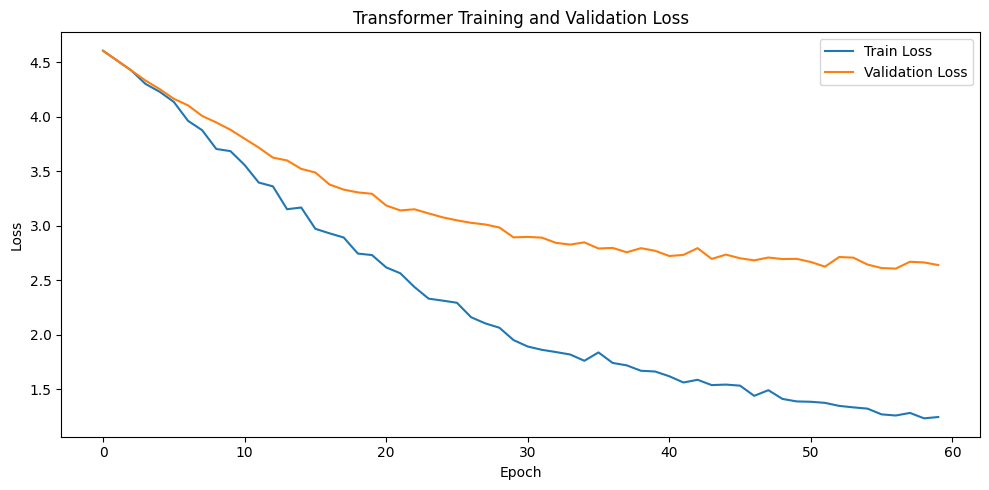

In [16]:
plt.figure(figsize=(10, 5))
plt.plot(history_df["train_loss"], label="Train Loss")
plt.plot(history_df["val_loss"], label="Validation Loss")
plt.title("Transformer Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.tight_layout()
plt.show()

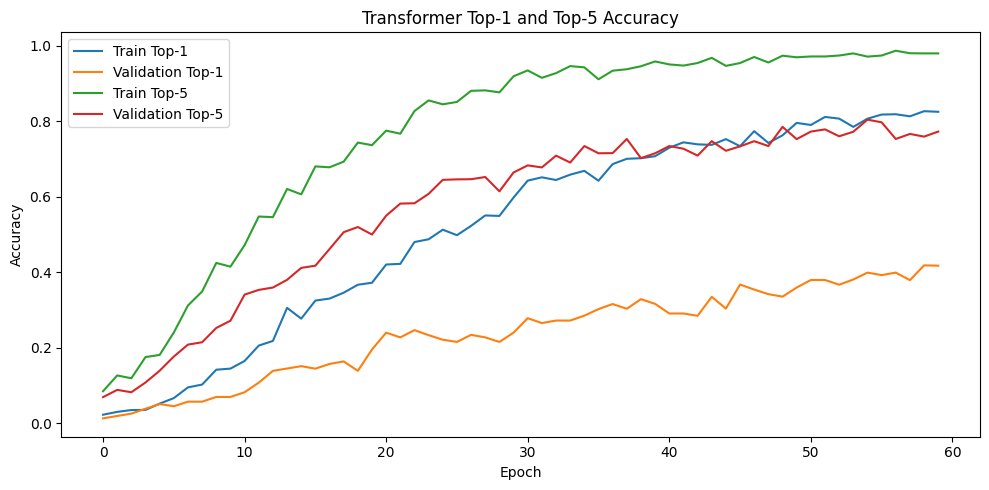

In [17]:
plt.figure(figsize=(10, 5))
plt.plot(history_df["train_top1"], label="Train Top-1")
plt.plot(history_df["val_top1"], label="Validation Top-1")
plt.plot(history_df["train_top5"], label="Train Top-5")
plt.plot(history_df["val_top5"], label="Validation Top-5")
plt.title("Transformer Top-1 and Top-5 Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.tight_layout()
plt.show()

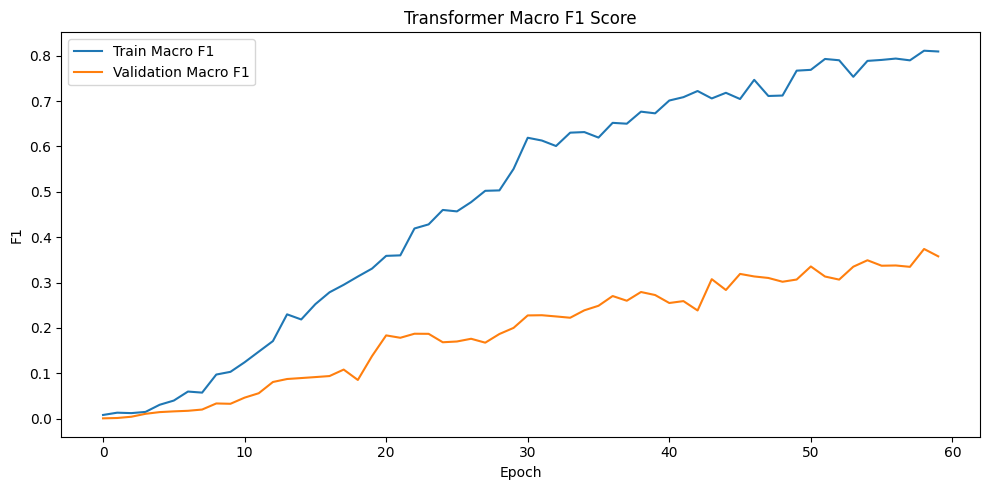

In [18]:
plt.figure(figsize=(10, 5))
plt.plot(history_df["train_f1"], label="Train Macro F1")
plt.plot(history_df["val_f1"], label="Validation Macro F1")
plt.title("Transformer Macro F1 Score")
plt.xlabel("Epoch")
plt.ylabel("F1")
plt.legend()
plt.tight_layout()
plt.show()

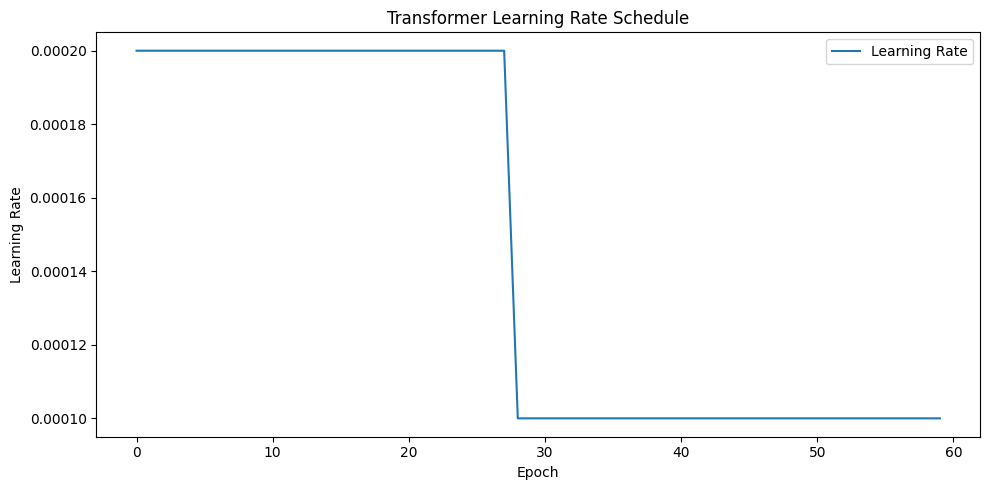

In [19]:
plt.figure(figsize=(10, 5))
plt.plot(history_df["lr"], label="Learning Rate")
plt.title("Transformer Learning Rate Schedule")
plt.xlabel("Epoch")
plt.ylabel("Learning Rate")
plt.legend()
plt.tight_layout()
plt.show()

## 9. Test set evaluation

In [20]:
checkpoint = torch.load(MODEL_PATH, map_location=device)

model = SignTransformerEncoder(
    input_size=checkpoint.get("input_size", INPUT_SIZE),
    num_classes=checkpoint.get("num_classes", NUM_CLASSES),
    d_model=checkpoint.get("d_model", 256),
    nhead=checkpoint.get("nhead", 4),
    num_layers=checkpoint.get("num_layers", 3),
    dim_feedforward=checkpoint.get("dim_feedforward", 512),
    dropout=checkpoint.get("dropout", 0.3),
    max_len=checkpoint.get("sequence_length", SEQUENCE_LENGTH) + 1
).to(device)

model.load_state_dict(checkpoint["model_state_dict"])
model.eval()

print("Loaded best Transformer model from epoch:", checkpoint["epoch"])
print("Best validation F1:", checkpoint["best_val_f1"])
print("Best validation Top-5:", checkpoint["best_val_top5"])

Loaded best Transformer model from epoch: 59
Best validation F1: 0.37404761904761896
Best validation Top-5: 0.759166669845581


In [21]:
def collect_predictions(model, loader, device):
    model.eval()

    all_labels = []
    all_preds = []
    all_probs = []

    with torch.no_grad():
        for x, y in tqdm(loader, desc="Collecting predictions"):
            x = x.to(device)
            y = y.to(device)

            outputs = model(x)
            probs = F.softmax(outputs, dim=1)
            preds = torch.argmax(probs, dim=1)

            all_labels.extend(y.cpu().numpy())
            all_preds.extend(preds.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())

    return np.array(all_labels), np.array(all_preds), np.array(all_probs)

In [22]:
y_true, y_pred, y_probs = collect_predictions(model, test_loader, device)

test_top1 = accuracy_score(y_true, y_pred)
test_f1 = f1_score(y_true, y_pred, average="macro", zero_division=0)

def numpy_top_k_accuracy(y_true, y_probs, k):
    correct = 0
    for true_label, prob in zip(y_true, y_probs):
        top_k_preds = np.argsort(prob)[-k:]
        if true_label in top_k_preds:
            correct += 1
    return correct / len(y_true)

test_top3 = numpy_top_k_accuracy(y_true, y_probs, k=3)
test_top5 = numpy_top_k_accuracy(y_true, y_probs, k=5)

print("=" * 80)
print("Transformer Test Set Evaluation")
print("=" * 80)
print(f"Test Top-1 Accuracy: {test_top1:.4f}")
print(f"Test Top-3 Accuracy: {test_top3:.4f}")
print(f"Test Top-5 Accuracy: {test_top5:.4f}")
print(f"Test Macro F1: {test_f1:.4f}")
print("=" * 80)

Transformer Test Set Evaluation
Test Top-1 Accuracy: 0.3354
Test Top-3 Accuracy: 0.6013
Test Top-5 Accuracy: 0.6709
Test Macro F1: 0.2830


## 10. Save Transformer result summary

This CSV will be used later in `08_compare_wlasl100_models.ipynb`.

In [23]:
RESULT_FILE = MODEL_DIR / "transformer_encoder_wlasl100_result_summary.csv"

result_df = pd.DataFrame([{
    "dataset": "WLASL100",
    "model": "Small Transformer Encoder",
    "clean_samples": len(df),
    "classes": NUM_CLASSES,
    "input_shape": f"(60, {INPUT_SIZE})",
    "velocity_features": USE_VELOCITY,
    "best_val_f1": checkpoint["best_val_f1"],
    "best_val_top5": checkpoint["best_val_top5"],
    "checkpoint_epoch": checkpoint["epoch"],
    "test_top1_accuracy": test_top1,
    "test_top3_accuracy": test_top3,
    "test_top5_accuracy": test_top5,
    "test_macro_f1": test_f1,
    "model_path": str(MODEL_PATH),
    "history_path": str(HISTORY_PATH)
}])

result_df.to_csv(RESULT_FILE, index=False)

print("Saved result summary to:")
print(RESULT_FILE)

result_df

Saved result summary to:
E:\Be_My_Ear\models\ASL\transformer_encoder_wlasl100_result_summary.csv


,dataset,model,clean_samples,classes,input_shape,velocity_features,best_val_f1,best_val_top5,checkpoint_epoch,test_top1_accuracy,test_top3_accuracy,test_top5_accuracy,test_macro_f1,model_path,history_path
0,WLASL100,Small Transformer Encoder,1013,100,"(60, 516)",True,0.374048,0.759167,59,0.335443,0.601266,0.670886,0.283,E:\Be_My_Ear\models\ASL\transformer_encoder_wl...,E:\Be_My_Ear\models\ASL\transformer_encoder_wl...


## 11. Prediction examples

In [24]:
with open(LABEL_MAP_FILE, "r", encoding="utf-8") as f:
    label_map = json.load(f)

test_examples = test_df.reset_index(drop=True).copy()

example_rows = []

for i in range(min(15, len(test_examples))):
    true_id = int(y_true[i])
    pred_id = int(y_pred[i])
    confidence = float(y_probs[i][pred_id])

    top5_ids = np.argsort(y_probs[i])[-5:][::-1]
    top5_glosses = [
        label_map[str(label_id)]["gloss"] if str(label_id) in label_map else str(label_id)
        for label_id in top5_ids
    ]

    example_rows.append({
        "video_id": test_examples.iloc[i]["video_id"],
        "true_gloss": label_map[str(true_id)]["gloss"] if str(true_id) in label_map else true_id,
        "predicted_gloss": label_map[str(pred_id)]["gloss"] if str(pred_id) in label_map else pred_id,
        "confidence": round(confidence, 4),
        "top5_predictions": ", ".join(top5_glosses)
    })

pd.DataFrame(example_rows)

,video_id,true_gloss,predicted_gloss,confidence,top5_predictions
0,56557,table,full,0.3260,"full, table, school, cheat, city"
1,69290,dark,dark,0.1800,"dark, kiss, cow, cool, bed"
2,57639,thanksgiving,thanksgiving,0.2711,"thanksgiving, white, thursday, thin, birthday"
3,64280,yes,short,0.3338,"short, last, apple, hot, man"
4,33273,like,yes,0.4568,"yes, same, chair, but, change"
5,10157,cheat,fish,0.3778,"fish, same, year, how, yes"
6,35452,medicine,study,0.2395,"study, school, cook, paper, chair"
7,36930,mother,mother,0.3536,"mother, blue, color, brown, who"
8,34831,many,what,0.3892,"what, want, finish, many, give"
9,62160,walk,walk,0.6159,"walk, clothes, chair, can, time"


## 12. Final summary

In [25]:
print("Final Transformer WLASL100 model summary")
print("----------------------------------------")
print(f"Dataset: WLASL100")
print(f"Clean samples: {len(df)}")
print(f"Classes: {NUM_CLASSES}")
print(f"Model: Small Transformer Encoder")
print(f"Input shape: (60, {INPUT_SIZE})")
print(f"Velocity features: {USE_VELOCITY}")
print(f"Best validation F1: {checkpoint['best_val_f1']:.4f}")
print(f"Best validation Top-5: {checkpoint['best_val_top5']:.4f}")
print(f"Test Top-1 Accuracy: {test_top1:.4f}")
print(f"Test Top-3 Accuracy: {test_top3:.4f}")
print(f"Test Top-5 Accuracy: {test_top5:.4f}")
print(f"Test Macro F1: {test_f1:.4f}")
print(f"Model saved to: {MODEL_PATH}")
print(f"History saved to: {HISTORY_PATH}")
print(f"Result summary saved to: {RESULT_FILE}")

Final Transformer WLASL100 model summary
----------------------------------------
Dataset: WLASL100
Clean samples: 1013
Classes: 100
Model: Small Transformer Encoder
Input shape: (60, 516)
Velocity features: True
Best validation F1: 0.3740
Best validation Top-5: 0.7592
Test Top-1 Accuracy: 0.3354
Test Top-3 Accuracy: 0.6013
Test Top-5 Accuracy: 0.6709
Test Macro F1: 0.2830
Model saved to: E:\Be_My_Ear\models\ASL\transformer_encoder_wlasl100.pt
History saved to: E:\Be_My_Ear\models\ASL\transformer_encoder_wlasl100_history.csv
Result summary saved to: E:\Be_My_Ear\models\ASL\transformer_encoder_wlasl100_result_summary.csv
